### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [2]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [8]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


We can now use MDP just as any other gym environment:

In [24]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

but it also has other methods that you'll need for Value Iteration

In [25]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [26]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

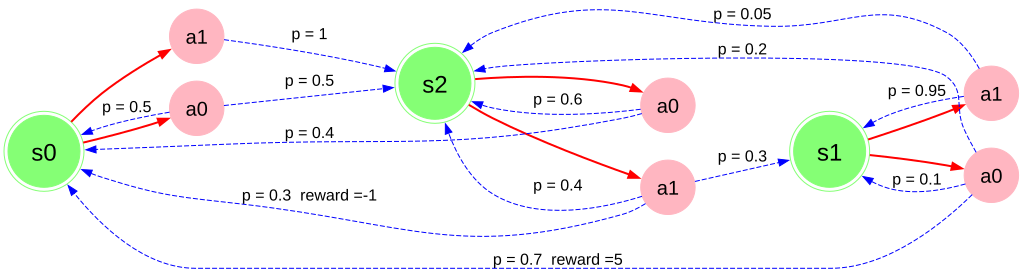

In [27]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [16]:
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """

    Q = 0
    for next_state in mdp.get_next_states(state, action):
        Q += mdp.get_transition_prob(state, action, next_state) * ( mdp.get_reward(state, action, next_state) + gamma * state_values[next_state])

    return Q

In [29]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [17]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0
    return max([get_action_value(mdp, state_values, state, action, gamma) for action in mdp.get_possible_actions(state)])

In [31]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

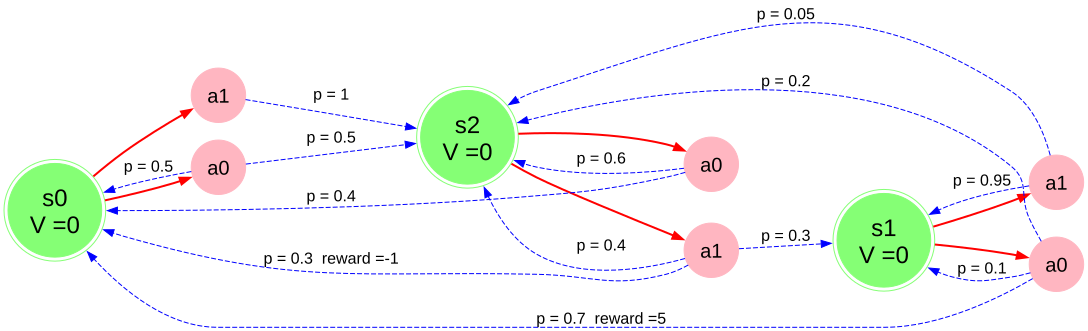

In [32]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {s:get_new_state_value(mdp, state_values, s, gamma) for s in state_values}

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

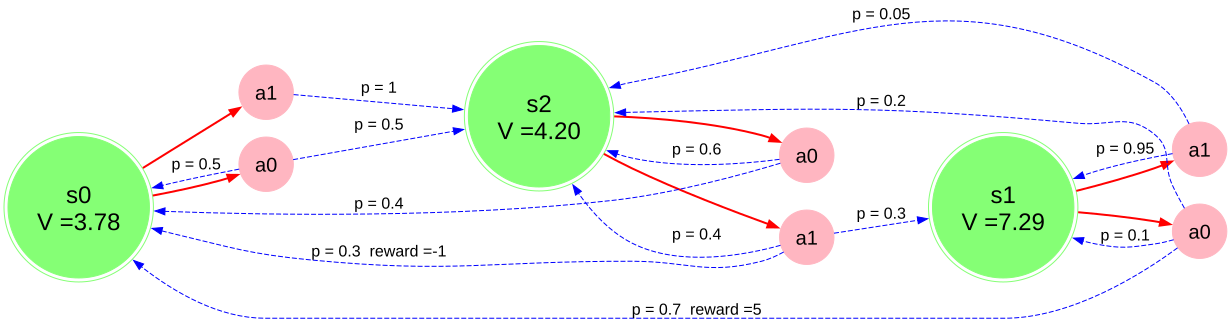

In [14]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [33]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [5]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None
    actions = mdp.get_possible_actions(state)
    index = np.argmax([get_action_value(mdp, state_values, state, action, gamma) for action in actions])
    return actions[index]

In [35]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

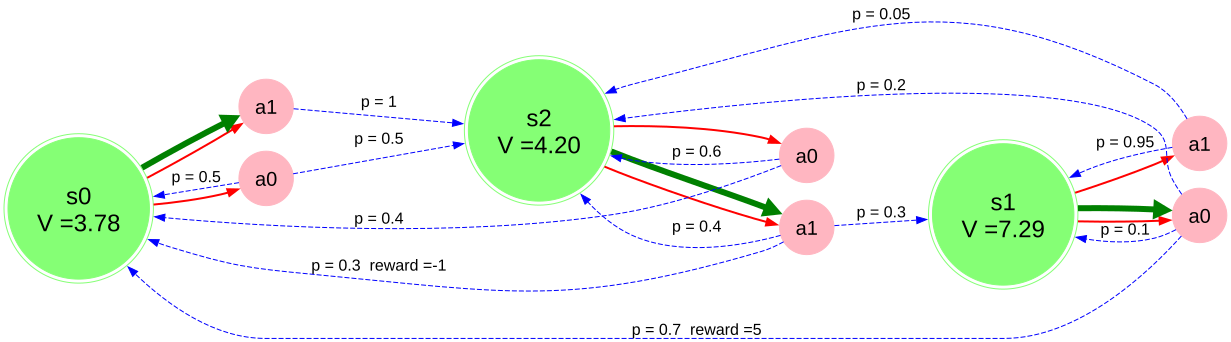

In [36]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [37]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

### Frozen lake

In [18]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [18]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {s:get_new_state_value(mdp, state_values, s, gamma) for s in state_values}

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [20]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [21]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


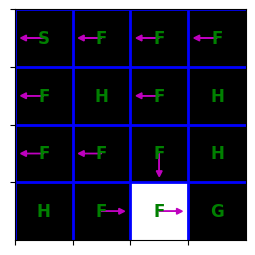

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


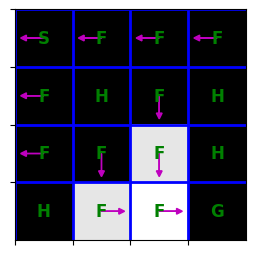

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


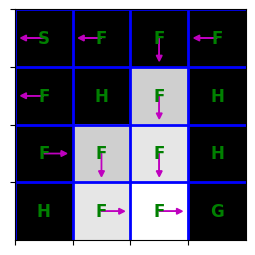

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


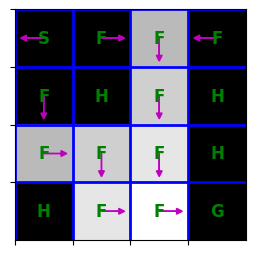

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


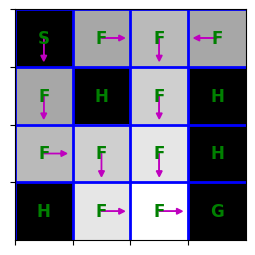

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


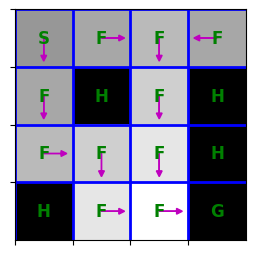

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


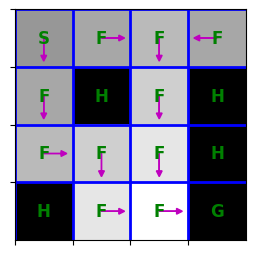

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


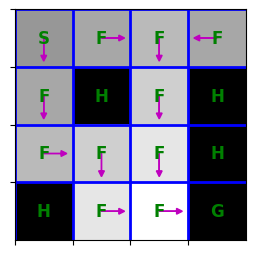

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


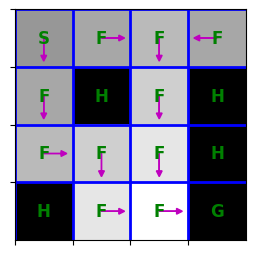

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


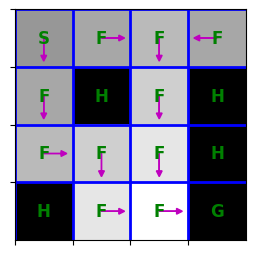

In [23]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


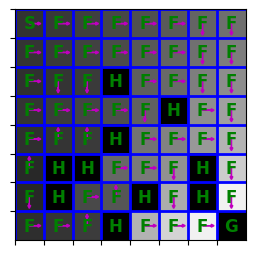

In [24]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [25]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [26]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.893
Well done!


In [27]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [29]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

Рассмотрим такой MDP

In [17]:
p = 0.634011
r_self = 3.159702
r_s2 = -1.565843
r_s1_penalty = -4.573627

transition_probs = {
    'S0': {
        'a0': {'S0': 1.0},
        'a1': {'S1': 1.0}
    },
    'S1': {
        'a0': {'S1': p, 'S2': 1 - p},
        'a1': {'S1': 1.0}
    },
    'S2': {
        'a0': {'S2': 1.0},
        'a1': {'S2': 1.0}
    }
}

rewards = {
    'S0': {
        'a0': {'S0': r_self}
    },
    'S1': {
        'a0': {'S1': r_s1_penalty, 'S2': r_s2}
    },
    'S2': {
        'a0': {'S2': 1.0},
        'a1': {'S2': 1.0}
    }
}

from mdp import MDP
from numpy import random
mdp = MDP(transition_probs, rewards, initial_state='S0')
# Feel free to change the initial_state

In [18]:
gamma = 0.95
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    if n_changes > 0:
        print("First Change!!")
        break
    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
iter    0   |   diff: 3.15970   |   V(start): 3.160 
N actions changed = 0 

after iteration 1
iter    0   |   diff: 2.84373   |   V(start): 6.003 
N actions changed = 0 

after iteration 2
iter    0   |   diff: 2.55936   |   V(start): 8.563 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 2.30342   |   V(start): 10.866 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 2.07308   |   V(start): 12.939 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 1.86577   |   V(start): 14.805 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 1.67920   |   V(start): 16.484 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 1.51128   |   V(start): 17.996 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 1.36015   |   V(start): 19.356 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 1.22413   |   V(start): 20.580 
N actions changed = 0 

after iteration 10
iter    0   |   diff: 1.

### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iteration.

**Proof**

The proof is straightforward and proceeds as follows.
1. $V^*$ is a fixed point of the operator $T$ since $T V^* = V^*$ is the Bellman optimality equation
2. Bellman operator is a contraction. By Banach theorem, a non-empty complete metric space with a contraction mapping admits a unique fixed point, which can be found by iterating the mapping starting with an arbitrary element of the metric space.
3. qed

### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

**Proof**
The proof is straightforward and proceeds as follows.

1. Let $V_m$ be the function $V$ after first $m$ iterations of async value iteration.
2. **Lemma (Non-increase of the norm).** For any iteration $m \geq 0$
$$\|V_{m+1} - V^*\|_\infty \le \|V_m - V^*\|_\infty.$$
*Proof.* On iteration $m+1$ only state $s_m$ is updated:
$$
V_{m+1}(s_m) = (T V_m)(s_m), \qquad V_{m+1}(s) = V_m(s) \;\; (s \neq s_m).
$$
For $s = s_m$
$$
|V_{m+1}(s_m)-V^*(s_m)| = |(T V_m)(s_m)-(T V^*)(s_m)| \leq \gamma \|V_m-V^*\|_\infty \leq \|V_m-V^*\|_\infty.
$$
For $s \neq s_m$
$$
|V_{m+1}(s)-V^*(s)| = |V_m(s)-V^*(s)| \le \|V_m-V^*\|_\infty.
$$
Hence every component of $V_{m+1}-V^* $ is bounded by $\|V_m-V^*\|_\infty$, so the supremum is also bounded. qed.
3. Let $k_i$ be the iteration, on which all unique states from $\mathcal{S}$ have appeared for the $i$th time. Since every state appears in the sequence infinitely often, $k_{i+1} > k_i$ and the sequence $\{k_i\}_{i=0}^{+\infty}$ is infinite.
4. Now we prove that $\forall i \geq 0: \|V_{k_{i+1}} - V^*\|_{\infty} \leq \gamma \|V_{k_{i}} - V^*\|_{\infty}$.
5. Consider an interval $[k_i, k_{i+1} - 1]$. Let $m_{s'}$ be the last iteration, on which the value function for state $s'$ was updated on this interval. Then for any state $s$
$$ V_{k_{i+1}-1}(s) = V_{m_s +1}(s) = (TV_{m_s})(s) $$
and consequently
$$| V_{k_{i+1}-1}(s) - V^*(s)| = | (TV_{m_s})(s) - (TV^*)(s)| \leq \gamma \|V_{m_s} - V^*\|_{\infty}.$$
6. By **Lemma** $\|V_{m_s} - V^*\|_{\infty} \leq \|V_{k_i} - V^*\|_{\infty}$.
7. Therefore
   $$\|V_{k_{i+1}-1} - V^*\|_{\infty} \leq \gamma  \|V_{k_i} - V^*\|_{\infty}.$$ Again by **Lemma**
   $$ \|V_{k_{i+1}} - V^*\|_{\infty}\leq \|V_{k_{i+1}-1} - V^*\|_{\infty} ,$$ which gives
   $$ \|V_{k_{i+1}} - V^*\|_{\infty} \leq \gamma \|V_{k_{i}} - V^*\|_{\infty} \leq \gamma^i \|V_{0} - V^*\|_{\infty} \to 0.$$
8. qed

# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [1]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

In [25]:
import numpy as np
def compute_vpi(mdp, policy, gamma):
    states = mdp.get_all_states()
    non_terminal = [s for s in states if not mdp.is_terminal(s)]
    n = len(non_terminal)
    if n == 0:
        return {s: 0.0 for s in states}
    
    idx = {s: i for i, s in enumerate(non_terminal)}
    A = np.zeros((n, n))
    b = np.zeros(n)
    
    for i, s in enumerate(non_terminal):
        a = policy[s]          # для нетерминальных action гарантирован не None
        total_reward = 0.0
        for next_s in states:
            p = mdp.get_transition_prob(s, a, next_s)
            r = mdp.get_reward(s, a, next_s)
            total_reward += p * r
            if not mdp.is_terminal(next_s):
                A[i, idx[next_s]] += p * gamma
        b[i] = total_reward
    
    A = np.eye(n) - A
    V_nonterm = np.linalg.solve(A, b)
    
    V = {s: 0.0 if mdp.is_terminal(s) else V_nonterm[idx[s]] for s in states}
    return V

In [9]:
gamma = 0.95
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(6.432568550643525), 's1': np.float64(10.086737548964734), 's2': np.float64(7.109681029658636)}


Once we've got new state values, it's time to update our policy.

In [15]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    states = mdp.get_all_states()
    return {state:get_optimal_action(mdp, vpi, state, gamma) for state in states}

In [11]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a1', 's1': 'a0', 's2': 'a1'}


__Main loop__

In [26]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    if policy is None:
        cur_policy = {}
        for s in mdp.get_all_states():
            if mdp.is_terminal(s):
                cur_policy[s] = None
            else:
                cur_policy[s] = np.random.choice(mdp.get_possible_actions(s))
    else:
        cur_policy = policy

    for _ in range(num_iter):
        vpi = compute_vpi(mdp, cur_policy, gamma)
        new_policy = compute_new_policy(mdp, vpi, gamma)
        if new_policy == cur_policy:
            break
        cur_policy = new_policy
    return vpi, cur_policy

__Your PI Results__

Сначала сравним на MDP из bonus 1

In [19]:
#<YOUR CODE: compare PI and VI on the MDP from bonus 1, then on small & large FrozenLake>

import time

p = 0.634011
r_self = 3.159702
r_s2 = -1.565843
r_s1_penalty = -4.573627

transition_probs_bonus = {
    'S0': {
        'a0': {'S0': 1.0},
        'a1': {'S1': 1.0}
    },
    'S1': {
        'a0': {'S1': p, 'S2': 1 - p},
        'a1': {'S1': 1.0}
    },
    'S2': {
        'a0': {'S2': 1.0},
        'a1': {'S2': 1.0}
    }
}

rewards_bonus = {
    'S0': {
        'a0': {'S0': r_self}
    },
    'S1': {
        'a0': {'S1': r_s1_penalty, 'S2': r_s2}
    },
    'S2': {
        'a0': {'S2': 1.0},
        'a1': {'S2': 1.0}
    }
}

mdp_bonus = MDP(transition_probs_bonus, rewards_bonus, initial_state='S0')

print("=" * 60)
print("Сравнение PI и VI на Bonus 1 MDP (gamma=0.95)")
print("=" * 60)

mdp = mdp_bonus
gamma = 0.95

# Policy Iteration
start = time.time()
v_pi, policy_pi = policy_iteration(mdp, gamma=gamma, num_iter=1000)
time_pi = time.time() - start
print(f"\nPI завершена за {time_pi:.4f} сек")
print("Политика PI:", policy_pi)

# Value Iteration
start = time.time()
state_values = {s: 0 for s in mdp.get_all_states()}
v_vi = value_iteration(mdp, state_values, gamma=gamma, num_iter=1000, min_difference=1e-5)
time_vi = time.time() - start
print(f"\nVI завершена за {time_vi:.4f} сек")
print("Значения V* (первые три):", {k: round(v_vi[k], 4) for k in list(v_vi)[:3]})

print(f"\nPI быстрее VI на {abs(time_vi - time_pi):.4f} сек" if time_pi < time_vi else f"VI быстрее PI на {abs(time_vi - time_pi):.4f} сек")

Сравнение PI и VI на Bonus 1 MDP (gamma=0.95)

PI завершена за 0.0007 сек
Политика PI: {'S0': 'a0', 'S1': 'a0', 'S2': 'a0'}
iter    0   |   diff: 3.15970   |   V(start): 3.160 
iter    1   |   diff: 3.00172   |   V(start): 6.161 
iter    2   |   diff: 2.85163   |   V(start): 9.013 
iter    3   |   diff: 2.70905   |   V(start): 11.722 
iter    4   |   diff: 2.57360   |   V(start): 14.296 
iter    5   |   diff: 2.44492   |   V(start): 16.741 
iter    6   |   diff: 2.32267   |   V(start): 19.063 
iter    7   |   diff: 2.20654   |   V(start): 21.270 
iter    8   |   diff: 2.09621   |   V(start): 23.366 
iter    9   |   diff: 1.99140   |   V(start): 25.357 
iter   10   |   diff: 1.89183   |   V(start): 27.249 
iter   11   |   diff: 1.79724   |   V(start): 29.047 
iter   12   |   diff: 1.70738   |   V(start): 30.754 
iter   13   |   diff: 1.62201   |   V(start): 32.376 
iter   14   |   diff: 1.54091   |   V(start): 33.917 
iter   15   |   diff: 1.46386   |   V(start): 35.381 
iter   16   |  

Для bonus 1 PI решилась намного быстрее, чем VI, потому что этот MDP очень маленький и проще решить маленькую СЛАУ, чем долго итерироваться

Теперь сравним на small Frozen lake

In [24]:
# ------------------------------------------------------------
# Сравнение на маленьком FrozenLake (4x4, slip_chance=0)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Сравнение PI и VI на FrozenLake 4x4 (slip=0, gamma=0.95)")
print("=" * 60)

from mdp import FrozenLakeEnv
mdp_small = FrozenLakeEnv(slip_chance=0)
gamma = 0.95

# Policy Iteration
start = time.time()
v_pi_small, policy_pi_small = policy_iteration(mdp_small, gamma=gamma, num_iter=1000)
time_pi_small = time.time() - start
print(f"\nPI завершена за {time_pi_small:.4f} сек")
print("Политика PI (первые 5 состояний):", dict(list(policy_pi_small.items())[:5]))

# Value Iteration
start = time.time()
state_values_small = {s: 0 for s in mdp_small.get_all_states()}
v_vi_small = value_iteration(mdp_small, state_values_small, gamma=gamma, num_iter=1000, min_difference=1e-5)
time_vi_small = time.time() - start
print(f"\nVI завершена за {time_vi_small:.4f} сек")
print("Значение V*(start):", round(v_vi_small[mdp_small._initial_state], 4))

if time_pi_small < time_vi_small:
    print(f"PI быстрее VI на {time_vi_small - time_pi_small:.4f} сек")
else:
    print(f"VI быстрее PI на {time_pi_small - time_vi_small:.4f} сек")


Сравнение PI и VI на FrozenLake 4x4 (slip=0, gamma=0.95)

PI завершена за 0.0089 сек
Политика PI (первые 5 состояний): {(0, 0): 'down', (0, 1): 'right', (0, 2): 'down', (0, 3): 'left', (1, 0): 'down'}
iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.95000   |   V(start): 0.000 
iter    2   |   diff: 0.90250   |   V(start): 0.000 
iter    3   |   diff: 0.85737   |   V(start): 0.000 
iter    4   |   diff: 0.81451   |   V(start): 0.000 
iter    5   |   diff: 0.77378   |   V(start): 0.774 
iter    6   |   diff: 0.00000   |   V(start): 0.774 

VI завершена за 0.0018 сек
Значение V*(start): 0.7738
VI быстрее PI на 0.0071 сек


Здесь уже MDP достаточно большой и СЛАУ в PI решается медленнее, чем итерируется VI

Сравним на big Frozen Lake

In [27]:
# ------------------------------------------------------------
# Сравнение на большом FrozenLake (8x8, slip_chance=0.1)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Сравнение PI и VI на FrozenLake 8x8 (slip=0.1, gamma=0.95)")
print("=" * 60)

mdp_large = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
gamma = 0.95

# Policy Iteration
start = time.time()
v_pi_large, policy_pi_large = policy_iteration(mdp_large, gamma=gamma, num_iter=1000)
time_pi_large = time.time() - start
print(f"\nPI завершена за {time_pi_large:.4f} сек")
# Покажем несколько действий для примера
print("Политика PI (первые 5 состояний):", dict(list(policy_pi_large.items())[:5]))

# Value Iteration
start = time.time()
state_values_large = {s: 0 for s in mdp_large.get_all_states()}
v_vi_large = value_iteration(mdp_large, state_values_large, gamma=gamma, num_iter=1000, min_difference=1e-5)
time_vi_large = time.time() - start
print(f"\nVI завершена за {time_vi_large:.4f} сек")
print("Значение V*(start):", round(v_vi_large[mdp_large._initial_state], 4))

if time_pi_large < time_vi_large:
    print(f"PI быстрее VI на {time_vi_large - time_pi_large:.4f} сек")
else:
    print(f"VI быстрее PI на {time_pi_large - time_vi_large:.4f} сек")


Сравнение PI и VI на FrozenLake 8x8 (slip=0.1, gamma=0.95)

PI завершена за 0.0789 сек
Политика PI (первые 5 состояний): {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'right', (0, 4): 'right'}
iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.76950   |   V(start): 0.000 
iter    2   |   diff: 0.65792   |   V(start): 0.000 
iter    3   |   diff: 0.56252   |   V(start): 0.000 
iter    4   |   diff: 0.50768   |   V(start): 0.000 
iter    5   |   diff: 0.45691   |   V(start): 0.000 
iter    6   |   diff: 0.41019   |   V(start): 0.000 
iter    7   |   diff: 0.36927   |   V(start): 0.000 
iter    8   |   diff: 0.33318   |   V(start): 0.000 
iter    9   |   diff: 0.30066   |   V(start): 0.000 
iter   10   |   diff: 0.27057   |   V(start): 0.000 
iter   11   |   diff: 0.24343   |   V(start): 0.000 
iter   12   |   diff: 0.21897   |   V(start): 0.000 
iter   13   |   diff: 0.19694   |   V(start): 0.197 
iter   14   |   diff: 0.10173   |   V(start): 0.28

По аналогичным причинам VI здесь быстрее (большой MDP -> долгое решение СЛАУ)

## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**

---

To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

**Proof** Let us fix a policy $\pi$. For any state $s$,
$$
\begin{aligned}
(T_\pi V)(s) &= \sum_{s'} P(s,\pi(s),s')\,R(s,\pi(s),s') \;+\; \gamma \sum_{s'} P(s,\pi(s),s')\,V(s'),\\
(T_\pi U)(s) &= \sum_{s'} P(s,\pi(s),s')\,R(s,\pi(s),s') \;+\; \gamma \sum_{s'} P(s,\pi(s),s')\,U(s').
\end{aligned}
$$
Since $V(s') \le U(s')$ for all $s'$ and $\gamma \ge 0$, $P(\cdot) \ge 0$, the second term in $(T_\pi V)(s)$ is less or equal to that in $(T_\pi U)(s)$. Hence $(T_\pi V)(s) \le (T_\pi U)(s)$. qed

#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

**Proof** For any state $s$,
$$
\begin{aligned}
|(T_\pi V)(s) - (T_\pi U)(s)|
&= \Bigl|\gamma \sum_{s'} P(s,\pi(s),s')\bigl(V(s')-U(s')\bigr)\Bigr| \\
&\le \gamma \sum_{s'} P(s,\pi(s),s')\,|V(s')-U(s')| \\
&\le \gamma \max_{s''}|V(s'')-U(s'')| \sum_{s'} P(s,\pi(s),s') \\
&= \gamma \|V-U\|_\infty.
\end{aligned}
$$
Taking the maximum over $s$ gives the desired inequality. qed

#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

**Proof** Let $\Pi$ be the set of all deterministic policies. Because $|\mathcal{S}|$ and $|\mathcal{A}|$ are finite, $\Pi$ is finite.

Consider the sequence of policies $\{\pi_k\}$ generated by the algorithm.  
From the update rule we have  
$$
T_{\pi_{k+1}}V_k = TV_k \ge T_{\pi_k}V_k = V_k.
$$  
The inequality holds pointwise because $TV_k$ is the maximum over actions.  

Applying the monotone operator $T_{\pi_{k+1}}$ repeatedly and using that $V_{k+1} = T_{\pi_{k+1}}V_{k+1}$ is the fixed point of $T_{\pi_{k+1}}$, we obtain  
$$
V_{k+1} \ge T_{\pi_{k+1}}V_k \ge V_k.
$$  
Thus the value functions are non‑decreasing: $V_{k+1}(s) \ge V_k(s)$ for every $s$.

If $\pi_{k+1} \neq \pi_k$ and $V_{k+1} = V_k$, then  
$V_k = T_{\pi_{k+1}}V_k = TV_k$ (since $V_{k+1}=T_{\pi_{k+1}}V_{k+1}=T_{\pi_{k+1}}V_k$). Hence $V_k$ satisfies the Bellman optimality equation, so $\pi_k$ is optimal.  
Therefore, if $\pi_{k+1} \neq \pi_k$ and $\pi_k$ is **not** optimal, we must have $V_{k+1} > V_k$ (pointwise with strict inequality in at least one state). In particular, $V_{k+1} \neq V_k$.

Now suppose the policy changes infinitely often. Since $\Pi$ is finite, by the pigeonhole principle there exist indices $i < j$ such that $\pi_i = \pi_j$. Choose the smallest such $j$. Between $i$ and $j$ there is at least one change. Let $k$ be the last index before $j$ where a change occurs, i.e., $\pi_{k+1} \neq \pi_k$ and $\pi_{k+1} = \pi_j$ (after $k$ the policy stays constant until $j$). Because the algorithm is deterministic, the same policy yields the same value function, so $V_{k+1} = V_j$. By monotonicity, $V_j \ge V_{k+1}$ and $V_{k+1} \ge V_k$.

If $\pi_k$ were not optimal, then from $\pi_{k+1} \neq \pi_k$ we would have $V_{k+1} > V_k$. Consequently, $V_j = V_{k+1} > V_k$. But $\pi_i = \pi_j$ implies $V_i = V_j$, while monotonicity gives $V_j \ge V_{k+1} > V_k \ge V_i$, a contradiction. Hence $\pi_k$ must be optimal. Once an optimal policy is reached, the algorithm will keep it unchanged. Thus there exists an index $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$, where $\pi^*$ is some optimal policy. qed